First five rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


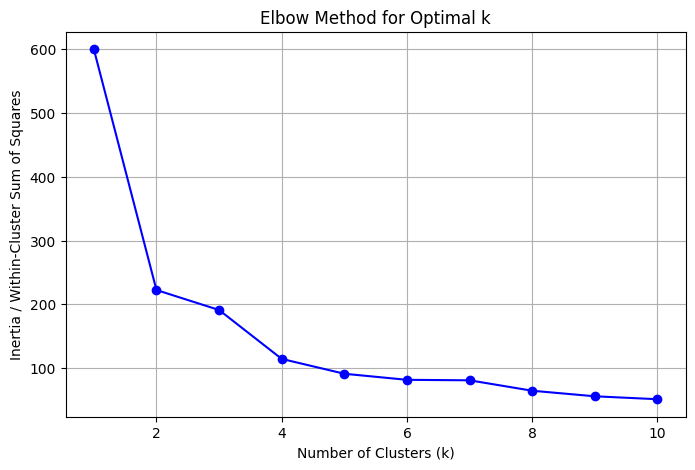


Silhouette Score: 0.480
Model Accuracy: 66.67%


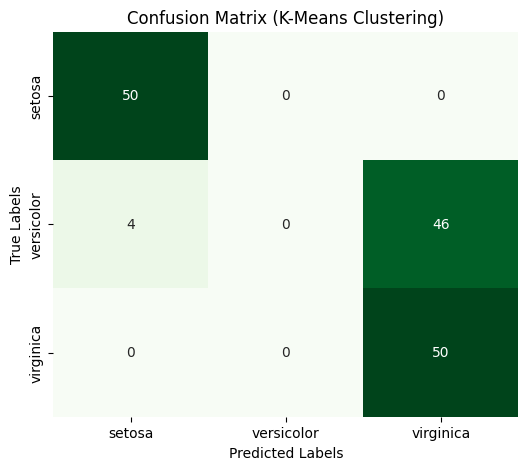

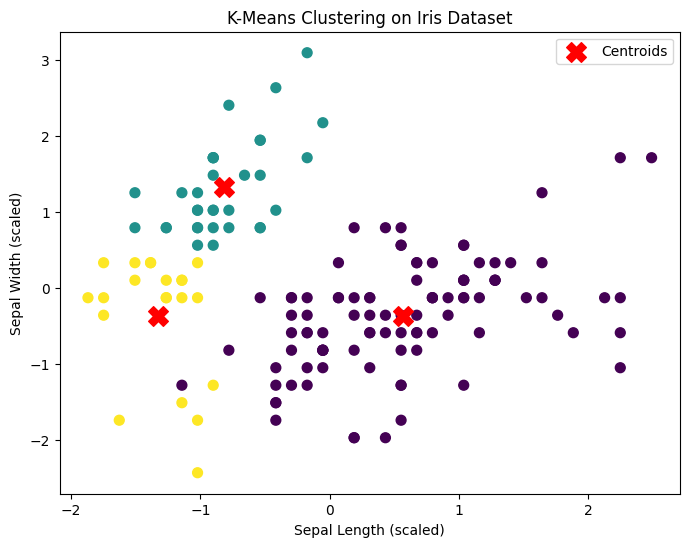


✅ Final Results:
Optimal Clusters (k): 3
Silhouette Score: 0.480
Accuracy: 66.67%


In [4]:
# --------------------------------------------------------------
# 🧠 ML Assignment: Iris Species Classification using K-Means Clustering
# --------------------------------------------------------------

# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from scipy.stats import mode

# --------------------------------------------------------------
# Step 1: Load the Iris Dataset
# --------------------------------------------------------------
iris = load_iris()
X = iris.data     # Features
y = iris.target   # Actual species labels (0 = Setosa, 1 = Versicolor, 2 = Virginica)

# Convert to DataFrame for easier handling
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
print("First five rows of the dataset:")
print(df.head())

# --------------------------------------------------------------
# Step 2: Feature Scaling
# --------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------------------------
# Step 3: Determine Optimal Number of Clusters (Elbow Method)
# --------------------------------------------------------------
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia / Within-Cluster Sum of Squares')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

# --------------------------------------------------------------
# Step 4: Apply K-Means Clustering with Optimal k=3
# --------------------------------------------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)
y_pred = kmeans.labels_

# --------------------------------------------------------------
# Step 5: Evaluate the Model
# --------------------------------------------------------------
sil_score = silhouette_score(X_scaled, y_pred)
print(f"\nSilhouette Score: {sil_score:.3f}")

# Map cluster labels to actual species for comparison
labels = np.zeros_like(y_pred)
for i in range(3):
    mask = (y_pred == i)
    labels[mask] = mode(y[mask])[0]

# Compute Accuracy
accuracy = accuracy_score(y, labels)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# --------------------------------------------------------------
# Step 6: Plot Confusion Matrix
# --------------------------------------------------------------
cm = confusion_matrix(y, labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix (K-Means Clustering)')
plt.show()

# --------------------------------------------------------------
# Step 7: Visualize the Clusters
# --------------------------------------------------------------
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_pred, cmap='viridis', s=50)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')
plt.title('K-Means Clustering on Iris Dataset')
plt.xlabel('Sepal Length (scaled)')
plt.ylabel('Sepal Width (scaled)')
plt.legend()
plt.show()

# --------------------------------------------------------------
# Step 8: Display Final Results
# --------------------------------------------------------------
print("\n✅ Final Results:")
print(f"Optimal Clusters (k): 3")
print(f"Silhouette Score: {sil_score:.3f}")
print(f"Accuracy: {accuracy * 100:.2f}%")
